# Model Comparison — Large Graphs (W2 con sampling Monte Carlo)

Variante di `comparison_models.ipynb` pensata per **grafi con molti più nodi**.

Il collo di bottiglia dell'originale è la distanza **Wasserstein-2**: usa la distribuzione
**completa** dei prodotti scalari `S = X @ X.T`, cioè `n²` valori ordinati per grafo
(es. `n=10000` → 100M valori ≈ 800 MB/grafo). Qui la W2 è stimata via **Monte Carlo**:
si campionano `m` coppie casuali `(i, j)` e si valuta `X[i]·X[j]`, con costo `O(m·d)`
**indipendente da n²**. L'embedding resta calcolato sul grafo grande intero, quindi si
testa fedelmente il grafo grande.

La distanza **Unmatched** usa `eigvalsh(X.T @ X)/n` (`O(n·d² + d³)`): scala già bene con
n e resta invariata.

Modelli: **SBM**, **CM**, **GM**, **CM2** — stessa analisi dell'originale (scatter +
curve NMI) ma a taglia grande.

In [1]:
import numpy as np
import random
import itertools
import pandas as pd
import os
import ot
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.sparse import csr_matrix
from scipy.stats import pareto
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from sklearn.metrics.pairwise import euclidean_distances
from EDRep_main.EDRep import NodeEmbedding
from tqdm.notebook import tqdm

## Funzioni di generazione

Identiche a `comparison_models.ipynb`

In [2]:
def generateSequence(outputfolder, model, args, n_graphs, start_idx=1, verbose=True, append_name='.csv'):
    for i in range(n_graphs):
        df = model(args)
        idx_str = str(start_idx + i).zfill(2)
        df.to_csv(outputfolder + '/EL' + idx_str + append_name, index=False)
        if verbose:
            print("[%--25s] %d%%" % ('='*(int(i/(n_graphs)*25)) + '>', (i+1)/(n_graphs)*100), end='\r')
    return


def DCSBM(args):
    C, c, l_nodes, theta, symmetric, make_connected = args
    k = len(np.unique(l_nodes))
    n = len(theta)
    c_v = C[l_nodes].T
    fs, ss = [], []
    if symmetric:
        first = np.random.choice(n, int(n*c/2), p=theta/n)
    else:
        first = np.random.choice(n, int(n*c), p=theta/n)
    for i in range(k):
        v = theta * c_v[i]
        first_sel = first[l_nodes[first] == i]
        fs.append(first_sel.tolist())
        second_sel = np.random.choice(n, len(first_sel), p=v/np.sum(v))
        ss.append(second_sel.tolist())
    fs = np.array(list(itertools.chain(*fs)))
    ss = np.array(list(itertools.chain(*ss)))
    if make_connected:
        idx = np.arange(n)[np.logical_not(np.isin(np.arange(n), fs))]
        fs = np.concatenate([fs, idx])
        ss = np.concatenate([ss, np.argmax(theta)*np.ones(len(idx))])
    edge_list = np.unique(np.column_stack((fs, ss)), axis=0)
    idx = edge_list[:,0] == edge_list[:,1]
    edge_list[:,1][idx] += 1
    edge_list[:,1][edge_list[:,1] == n] = 0
    if symmetric:
        df = pd.DataFrame(columns=['i', 'j'])
        M = np.maximum(edge_list[:,0], edge_list[:,1])
        m = np.minimum(edge_list[:,0], edge_list[:,1])
        df.i = np.concatenate([M, m])
        df.j = np.concatenate([m, M])
    else:
        df = pd.DataFrame({'i': edge_list[:,0], 'j': edge_list[:,1]})
    return df


def GeometricModel(args):
    X, d, beta = args
    n = np.shape(X)[0]
    no = (X**2)@np.ones(2)
    D = np.zeros((n, n))
    for i in range(n):
        D[i] += no
        D[:,i] += no
    D -= 2*X@X.T
    D = np.sqrt(np.abs(D))
    P = np.exp(-beta*D)
    P = P - np.diag(np.diag(P))
    p = P@np.ones(n)
    P = np.diag(p**(-1)).dot(P)
    idx1 = np.concatenate([np.ones(int(d/2))*i for i in range(n)])
    idx2 = np.concatenate([np.random.choice(np.arange(n), int(d/2), p=P[i], replace=False) for i in range(n)])
    df = pd.DataFrame(columns=['i', 'j'])
    df.i = np.concatenate([idx1, idx2])
    df.j = np.concatenate([idx2, idx1])
    return df


def _sample_pareto(N, alpha, loc=0, scale=1, mean=None):
    b = alpha-1
    r = pareto.rvs(b, loc=loc, scale=scale, size=N)
    if mean:
        r = (r/r.mean()*mean).round()
    return r


def getDegreeFromPareto(n, c, alpha):
    theta = np.random.uniform(3, 15, n)**alpha
    theta = theta/np.mean(theta)
    degree_sequence = np.maximum(np.random.binomial(n-1, np.minimum(1,theta/n*c)), np.ones(n))
    return degree_sequence


def gen_with_conf_model(args):
    n, c, alpha = args
    degree_sequence = np.round(getDegreeFromPareto(n, c, alpha)).astype(int)
    if sum(degree_sequence) % 2 != 0:
        degree_sequence[-1] += 1
    G = nx.configuration_model(degree_sequence)
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    return pd.DataFrame(G.edges(), columns=['i', 'j'])


def gen_cm_via_dcsbm(args):
    n, c, alpha, symmetric, make_connected = args
    theta = np.random.uniform(3, 10, n) ** alpha
    theta = theta / np.mean(theta)
    ell = np.zeros(n, dtype=int)
    C = np.array([[c]])
    return DCSBM((C, c, ell, theta, symmetric, make_connected))


def compute_cin_cout(c, k, alpha):
    c_out = c - alpha * np.sqrt(c)
    c_in = k*c - (k-1)*c_out
    return c_in, c_out

## embedding, clustering e distanze campionate

`precompute_features_sampled` è la novità: per ogni embedding calcola gli autovalori
esatti (Unmatched) ma **stima** la distribuzione di `X @ X.T` campionando `m` coppie
casuali, senza mai materializzare la matrice `n×n`. Fissando `m_samples` globale, tutti
i campioni hanno lunghezza `m` → la W2 1D è sempre la formula chiusa
`sqrt(mean((sort(a) - sort(b))²))`.

In [3]:
def get_adj(filepath):
    df = pd.read_csv(filepath)
    G = nx.from_pandas_edgelist(df, 'i', 'j')
    return nx.adjacency_matrix(G).astype(float)


def node_embedding(g, dim_embedding, seed=42):
    rdn_state = np.random.get_state()
    random.seed(seed); np.random.seed(seed)
    X_total = NodeEmbedding(g, dim=dim_embedding, k=1, verbose=False).X
    np.random.set_state(rdn_state)
    return X_total


def create_embeddings(path_files, dim):
    embeddings = []
    for file in tqdm(path_files, desc="Calcolando embeddings", leave=False):
        embeddings.append(node_embedding(get_adj(file), dim))
    return embeddings


def NMF_kmeans(M, k):
    n, _ = M.shape
    Mt = M + np.eye(n)*np.mean(M[M.nonzero()])
    Mt = Mt / np.mean(Mt)
    Y = NMF(n_components=k, max_iter=2000).fit(Mt).components_
    kmeans = KMeans(n_clusters=k, n_init=10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))


def ClusterNMF(M, k):
    est_l, score = NMF_kmeans(M, k)
    for _ in range(20):
        est_l_, score_ = NMF_kmeans(M, k)
        if score_ < score:
            score = score_; est_l = est_l_
    return est_l


def sample_scalar_products(X, m_samples, rng):
    """Campiona m_samples coppie (i, j) e ritorna i prodotti scalari X[i].X[j].

    Costo O(m_samples * d) e memoria O(m_samples * d): non materializza mai X @ X.T."""
    n = len(X)
    ii = rng.integers(0, n, m_samples)
    jj = rng.integers(0, n, m_samples)
    return np.einsum('kd,kd->k', X[ii], X[jj])


def precompute_features_sampled(embeddings, m_samples, seed=0):
    """Pre-calcola le feature per le distanze, in versione scalabile.

    - Unmatched: autovalori esatti di X.T@X / n  (O(n*d^2 + d^3), scala con n).
    - Wasserstein: distribuzione di X@X.T STIMATA via Monte Carlo su m_samples coppie,
      invece dei n^2 valori completi -> indipendente da n^2.

    Con m_samples fisso, tutti i campioni hanno lunghezza m -> la W2 1D usa sempre la
    formula chiusa sqrt(mean((sort(a)-sort(b))^2)).
    """
    rng = np.random.default_rng(seed)
    eigenvalues, S_sorted_list = [], []
    for X in tqdm(embeddings, desc="Pre-computing (sampled)", leave=False):
        n = len(X)
        eigenvalues.append(np.linalg.eigvalsh(X.T @ X) / n)
        S_sorted_list.append(np.sort(sample_scalar_products(X, m_samples, rng)))
    return eigenvalues, S_sorted_list


def compute_distance_matrices(all_emb, labels, model_name, m_samples, seed=0):
    """Unmatched (esatta, vettorizzata) + Wasserstein (campionata Monte Carlo).

    Identica all'originale tranne la pre-computazione campionata: vedi
    precompute_features_sampled. Poiche' i campioni hanno tutti lunghezza m_samples,
    il ramo della formula chiusa e' sempre attivo (il fallback POT resta per sicurezza).
    """
    N = len(all_emb)
    pairs = list(itertools.combinations(range(N), 2))

    eigenvalues, S_sorted_list = precompute_features_sampled(all_emb, m_samples, seed)

    eig_matrix = np.stack(eigenvalues)
    D_unmatched = euclidean_distances(eig_matrix)

    w2_vals = []
    for i, j in tqdm(pairs, desc=f"{model_name} W2 (sampled)", leave=True):
        s1, s2 = S_sorted_list[i], S_sorted_list[j]
        if len(s1) == len(s2):
            w2_vals.append(np.sqrt(np.mean((s1 - s2) ** 2)))
        else:
            w2_vals.append(ot.wasserstein_1d(s1, s2, p=2) ** 0.5)

    D_wasserstein = squareform(w2_vals)

    categories = []
    for i, j in pairs:
        a_i, a_j = labels[i], labels[j]
        if a_i == a_j:
            categories.append(f"{model_name} {a_i:.2f}")
        else:
            a_min, a_max = sorted([a_i, a_j])
            categories.append(f"{a_min:.2f} vs {a_max:.2f}")

    df = pd.DataFrame({
        'Unmatched':   [D_unmatched[i, j] for i, j in pairs],
        'Wasserstein': w2_vals,
        'Type':        categories,
    })
    return df, D_unmatched, D_wasserstein

## Parametri

`n_nodes` grande e configurabile (default 5000; commenta/aumenta a 10000+ per stressare
lo scaling). `m_samples` controlla quante coppie casuali stimano la W2: più alto =
stima più accurata, costo lineare in `m_samples` e indipendente da `n`.

In [4]:
n_nodes   = 1000     # taglia grande; prova 10000+ per testare lo scaling
m_samples = 200_000     # coppie campionate per la stima Monte Carlo della W2
gamma = 0.8
symmetric = True
make_connected = True
c = 10
dim = 32
n_graphs = 15           # ridotto rispetto all'originale (30) per tenere i tempi gestibili
sample_seed = 0

sbm_alphas = [0, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
cm_alphas  = [0, 0.5, 1, 1.5, 2, 2.5, 3]
gm_betas   = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
cm2_alphas = [0, 0.5, 1, 1.5, 2, 2.5, 3]

base = os.path.join("data", "synthetic_graphs", "large")
base_sbm = os.path.join(base, "generated_sbm")
base_cm  = os.path.join(base, "generated_cm")
base_gm  = os.path.join(base, "generated_gm")
base_cm2 = os.path.join(base, "generated_cm2")
print("n_nodes =", n_nodes, "| m_samples =", m_samples,
      "| rapporto m/n^2 =", m_samples / n_nodes**2)

n_nodes = 1000 | m_samples = 200000 | rapporto m/n^2 = 0.2


## Validazione del sampling

A taglia moderata (dove la W2 esatta è ancora calcolabile) confrontiamo la W2 **esatta**
(distribuzione completa `X @ X.T`, come nell'originale) con quella **campionata**. Ci
aspettiamo errore relativo basso e correlazione molto alta tra le due su molte coppie.

Coppie confrontate: 28
Errore relativo W2 sampled vs exact -> mediano: 0.0196, max: 4.1127
Correlazione (exact, sampled): 0.99879


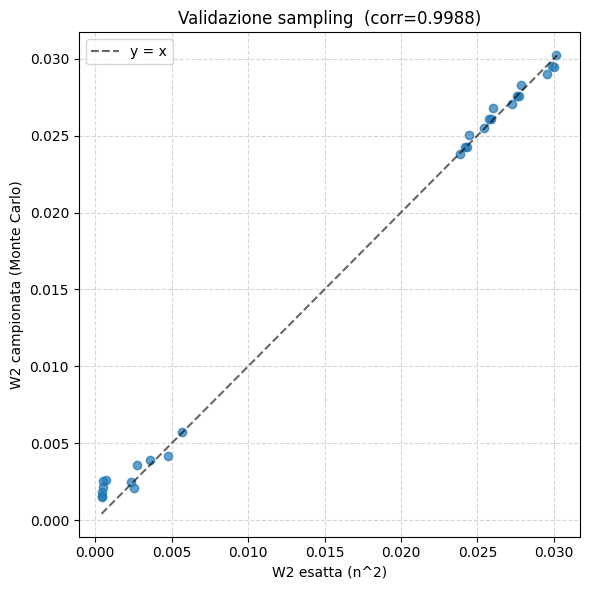

In [5]:
def w2_exact_sorted(X):
    """Distribuzione completa ordinata di X@X.T (come precompute_features originale)."""
    return np.sort((X @ X.T).ravel())


def w2_from_sorted(s1, s2):
    return np.sqrt(np.mean((s1 - s2) ** 2))


# Genera alcuni grafi a taglia moderata da modelli diversi -> embedding -> W2 exact vs sampled
n_val = 1500
n_val_graphs = 8
rng_val = np.random.default_rng(sample_seed)

val_embeddings = []
# mezzo set ER-like (SBM alpha=0), mezzo strutturato (SBM alpha=1.5)
theta_v = np.ones(n_val)
k_v = 4
l_v = np.zeros(n_val, dtype=int)
for i in range(k_v):
    l_v[i*(n_val//k_v):(i+1)*(n_val//k_v)] = i
for a in [0.0, 1.5]:
    c_in, c_out = compute_cin_cout(c, k_v, a)
    C_v = np.ones((k_v, k_v)) * c_out + np.diag(np.ones(k_v)) * (c_in - c_out)
    for _ in range(n_val_graphs // 2):
        df_v = DCSBM((C_v, c, l_v, theta_v, symmetric, make_connected))
        G = nx.from_pandas_edgelist(df_v, 'i', 'j')
        A = nx.adjacency_matrix(G).astype(float)
        val_embeddings.append(node_embedding(A, dim))

exact_sorted = [w2_exact_sorted(X) for X in val_embeddings]
samp_sorted  = [np.sort(sample_scalar_products(X, m_samples, rng_val)) for X in val_embeddings]

exact_w2, samp_w2 = [], []
for i, j in itertools.combinations(range(len(val_embeddings)), 2):
    exact_w2.append(w2_from_sorted(exact_sorted[i], exact_sorted[j]))
    samp_w2.append(w2_from_sorted(samp_sorted[i], samp_sorted[j]))

exact_w2 = np.array(exact_w2); samp_w2 = np.array(samp_w2)
rel_err = np.abs(samp_w2 - exact_w2) / (exact_w2 + 1e-12)
corr = np.corrcoef(exact_w2, samp_w2)[0, 1]
print(f"Coppie confrontate: {len(exact_w2)}")
print(f"Errore relativo W2 sampled vs exact -> mediano: {np.median(rel_err):.4f}, max: {rel_err.max():.4f}")
print(f"Correlazione (exact, sampled): {corr:.5f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(exact_w2, samp_w2, alpha=0.7)
lims = [min(exact_w2.min(), samp_w2.min()), max(exact_w2.max(), samp_w2.max())]
ax.plot(lims, lims, 'k--', alpha=0.6, label='y = x')
ax.set_xlabel("W2 esatta (n^2)"); ax.set_ylabel("W2 campionata (Monte Carlo)")
ax.set_title(f"Validazione sampling  (corr={corr:.4f})")
ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

## Helper di pipeline

`run_model_pipeline` evita di duplicare i 4 blocchi per-modello: data una funzione di
generazione, una `args_fn(param)` che costruisce gli argomenti per ogni valore del
parametro, e la lista dei parametri, esegue genera→embedda→distanze (campionate) e
ritorna `df, D_unmatched, D_wasserstein, labels`. `plot_scatter` e `nmi_curves`
replicano i grafici dell'originale.

In [6]:
def run_model_pipeline(model_name, base_folder, gen_fn, args_fn, params,
                       n_graphs, dim, m_samples, sample_seed, verbose=True):
    all_emb, labels = [], []
    for p in params:
        folder = os.path.join(base_folder, f"param_{p}")
        os.makedirs(folder, exist_ok=True)
        if verbose:
            print(f"Generazione {model_name} param={p} -> {folder}")
        generateSequence(folder, gen_fn, args_fn(p), n_graphs, start_idx=1, verbose=verbose)
        if verbose:
            print()
        files = sorted(glob.glob(os.path.join(folder, "*.csv")))
        all_emb.extend(create_embeddings(files, dim))
        labels.extend([p] * len(files))
    df, D_u, D_w = compute_distance_matrices(all_emb, labels, model_name,
                                             m_samples=m_samples, seed=sample_seed)
    return df, D_u, D_w, labels


def _keep_types(model_name, params):
    base = params[0]
    keep = [f"{model_name} {base:.2f}"]
    for p in params[1:]:
        lo, hi = sorted([base, p])
        keep.append(f"{lo:.2f} vs {hi:.2f}")
    return keep


def plot_scatter(df, model_name, params, hue_title):
    keep = _keep_types(model_name, params)
    df_f = df[df['Type'].isin(keep)]
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(data=df_f, x='Unmatched', y='Wasserstein',
                    hue='Type', hue_order=keep, palette='tab10', alpha=0.7, s=50, ax=ax)
    ax.set_title(f"{model_name}: Unmatched vs Wasserstein (n={n_nodes}, sampled)", fontsize=15)
    ax.set_xlabel("Unmatched", fontsize=12); ax.set_ylabel("Wasserstein", fontsize=12)
    ax.legend(title=hue_title, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout(); plt.show()


def nmi_global(D_u, D_w, params, n_graphs, model_name):
    l_true = np.concatenate([[i]*n_graphs for i in range(len(params))])
    k_all = len(params)
    nmi_u = NMI(ClusterNMF(D_u, k_all), l_true)
    nmi_w = NMI(ClusterNMF(D_w, k_all), l_true)
    print(f"{model_name} NMI globale - Unmatched:   {nmi_u:.4f}")
    print(f"{model_name} NMI globale - Wasserstein: {nmi_w:.4f}")
    return nmi_u, nmi_w


def nmi_curves(D_u, D_w, params, n_graphs):
    nmi_u_curve, nmi_w_curve = [], []
    for i in range(len(params)):
        if i == 0:
            nmi_u_curve.append(0.0); nmi_w_curve.append(0.0); continue
        idx = np.concatenate([np.arange(0, n_graphs), np.arange(i*n_graphs, (i+1)*n_graphs)])
        l_sub = np.concatenate([np.zeros(n_graphs), np.ones(n_graphs)])
        nmi_u_curve.append(NMI(ClusterNMF(D_u[np.ix_(idx, idx)], k=2), l_sub))
        nmi_w_curve.append(NMI(ClusterNMF(D_w[np.ix_(idx, idx)], k=2), l_sub))
    return nmi_u_curve, nmi_w_curve


def plot_nmi_curves(params, nmi_u_curve, nmi_w_curve, model_name, xlabel):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.plot(params, nmi_u_curve, marker='o', color='steelblue')
    ax1.set_title(f"{model_name}: NMI vs {xlabel} (Unmatched)", fontsize=14)
    ax1.set_xlabel(xlabel); ax1.set_ylabel("NMI")
    ax1.set_xticks(params); ax1.set_ylim(-0.05, 1.05); ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.plot(params, nmi_w_curve, marker='s', color='darkorange')
    ax2.set_title(f"{model_name}: NMI vs {xlabel} (Wasserstein)", fontsize=14)
    ax2.set_xlabel(xlabel); ax2.set_ylabel("NMI")
    ax2.set_xticks(params); ax2.set_ylim(-0.05, 1.05); ax2.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

## 1. Stochastic Block Model (SBM)

k=4 comunità. `alpha=0` → ER; `alpha` crescente → comunità più nette.

In [7]:
k_sbm = 4
theta_sbm = np.ones(n_nodes)
l_sbm = np.zeros(n_nodes, dtype=int)
for i in range(k_sbm):
    l_sbm[i*(n_nodes//k_sbm):(i+1)*(n_nodes//k_sbm)] = i

def sbm_args(a):
    c_in, c_out = compute_cin_cout(c, k_sbm, a)
    C_sbm = np.ones((k_sbm, k_sbm)) * c_out + np.diag(np.ones(k_sbm)) * (c_in - c_out)
    return (C_sbm, c, l_sbm, theta_sbm, symmetric, make_connected)

df_sbm, D_unmatched_sbm, D_wasserstein_sbm, labels_sbm = run_model_pipeline(
    "SBM", base_sbm, DCSBM, sbm_args, sbm_alphas, n_graphs, dim, m_samples, sample_seed)

Generazione SBM param=0 -> data\synthetic_graphs\large\generated_sbm\param_0
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione SBM param=0.5 -> data\synthetic_graphs\large\generated_sbm\param_0.5
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione SBM param=0.75 -> data\synthetic_graphs\large\generated_sbm\param_0.75
[=======================> ] 100%


...

Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione SBM param=2 -> data\synthetic_graphs\large\generated_sbm\param_2
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Pre-computing (sampled):   0%|          | 0/120 [00:00<?, ?it/s]

SBM W2 (sampled):   0%|          | 0/7140 [00:00<?, ?it/s]

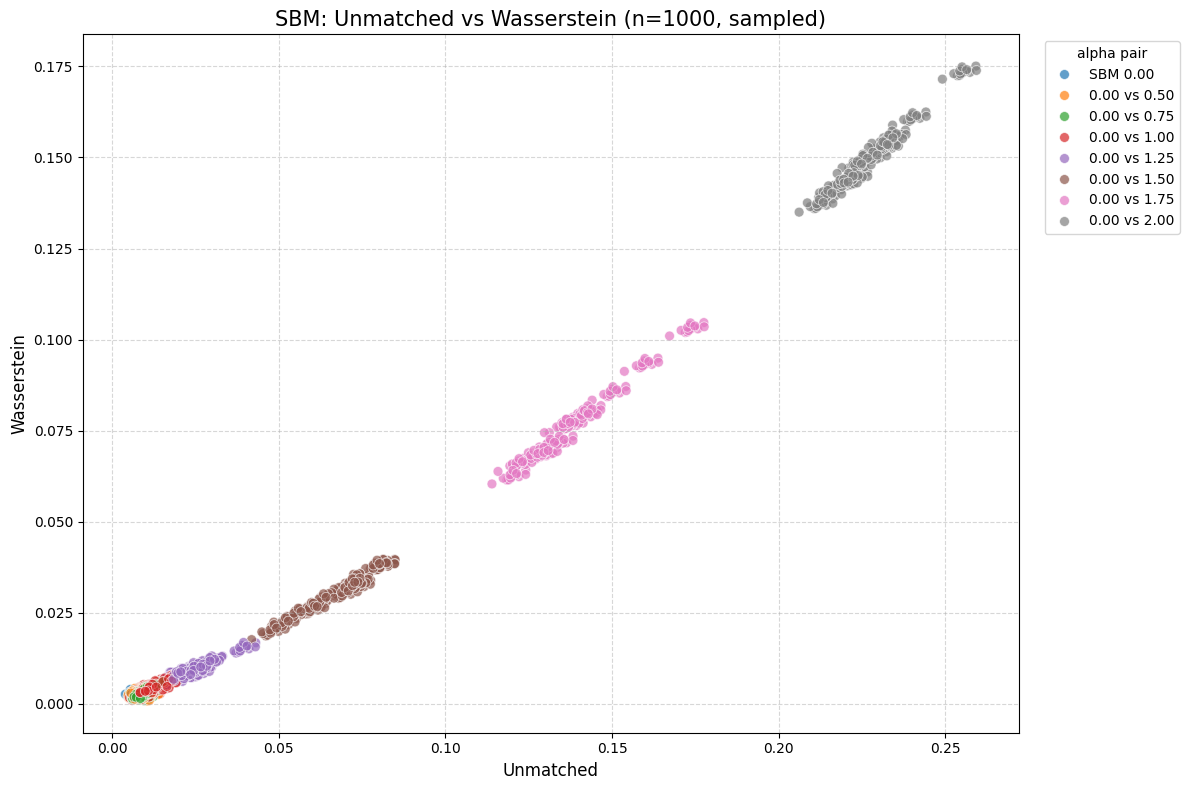

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number o

SBM NMI globale - Unmatched:   0.7170
SBM NMI globale - Wasserstein: 0.7488


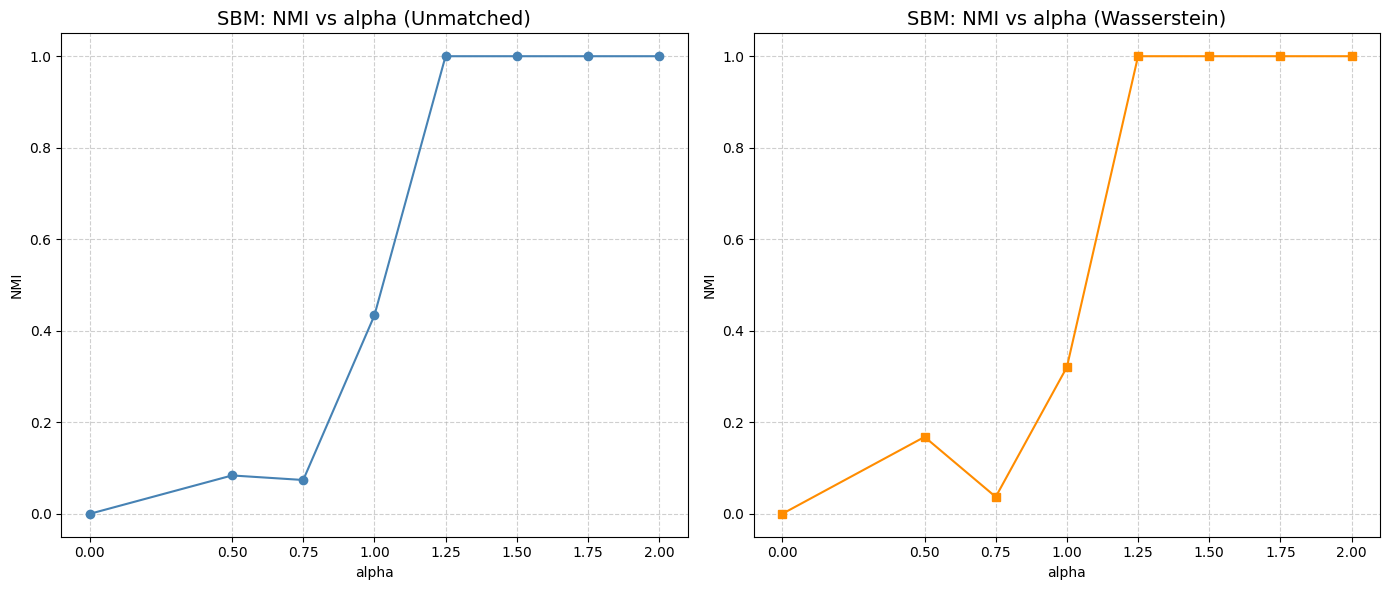

In [8]:
plot_scatter(df_sbm, "SBM", sbm_alphas, "alpha pair")
nmi_global(D_unmatched_sbm, D_wasserstein_sbm, sbm_alphas, n_graphs, "SBM")
nmi_u_sbm_curve, nmi_w_sbm_curve = nmi_curves(D_unmatched_sbm, D_wasserstein_sbm, sbm_alphas, n_graphs)
plot_nmi_curves(sbm_alphas, nmi_u_sbm_curve, nmi_w_sbm_curve, "SBM", "alpha")

## 2. Configuration Model (CM)

`alpha=0` → gradi binomiali (ER-like); `alpha` crescente → coda Pareto (hub).

In [9]:
df_cm, D_unmatched_cm, D_wasserstein_cm, labels_cm = run_model_pipeline(
    "CM", base_cm, gen_with_conf_model, lambda a: (n_nodes, c, a),
    cm_alphas, n_graphs, dim, m_samples, sample_seed)

Generazione CM param=0 -> data\synthetic_graphs\large\generated_cm\param_0
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione CM param=0.5 -> data\synthetic_graphs\large\generated_cm\param_0.5
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione CM param=1 -> data\synthetic_graphs\large\generated_cm\param_1
[=======================> ] 100%


...

Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione CM param=3 -> data\synthetic_graphs\large\generated_cm\param_3
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Pre-computing (sampled):   0%|          | 0/105 [00:00<?, ?it/s]

CM W2 (sampled):   0%|          | 0/5460 [00:00<?, ?it/s]

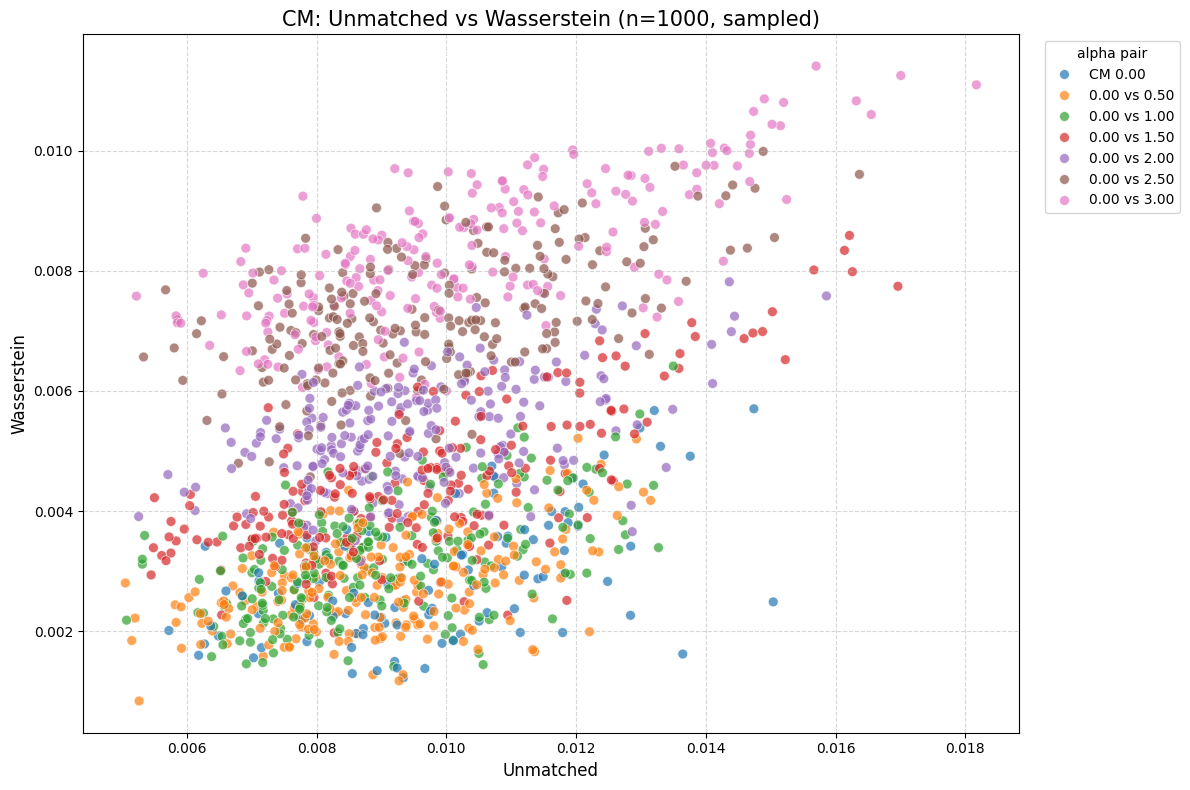

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


CM NMI globale - Unmatched:   0.1140
CM NMI globale - Wasserstein: 0.5043


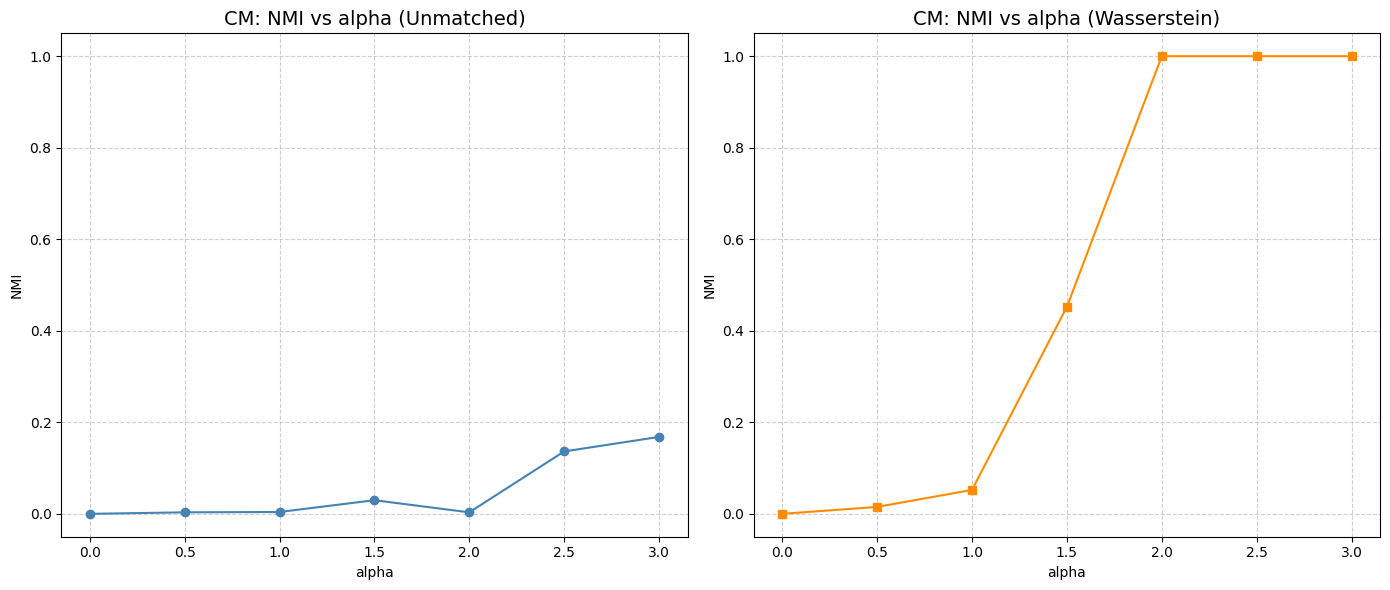

In [10]:
plot_scatter(df_cm, "CM", cm_alphas, "alpha pair")
nmi_global(D_unmatched_cm, D_wasserstein_cm, cm_alphas, n_graphs, "CM")
nmi_u_cm_curve, nmi_w_cm_curve = nmi_curves(D_unmatched_cm, D_wasserstein_cm, cm_alphas, n_graphs)
plot_nmi_curves(cm_alphas, nmi_u_cm_curve, nmi_w_cm_curve, "CM", "alpha")

## 3. Geometric Model (GM)

`beta=0` → connessioni uniformi (ER-like); `beta` crescente → località spaziale.

In [11]:
r_gm = np.random.uniform(0, 1, n_nodes)
theta_gm = np.random.uniform(0, 2*np.pi, n_nodes)
X_gm = np.column_stack([r_gm*np.cos(theta_gm), r_gm*np.sin(theta_gm)])

df_gm, D_unmatched_gm, D_wasserstein_gm, labels_gm = run_model_pipeline(
    "GM", base_gm, GeometricModel, lambda b: (X_gm, c, b),
    gm_betas, n_graphs, dim, m_samples, sample_seed)

Generazione GM param=0 -> data\synthetic_graphs\large\generated_gm\param_0
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione GM param=0.5 -> data\synthetic_graphs\large\generated_gm\param_0.5
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione GM param=1 -> data\synthetic_graphs\large\generated_gm\param_1
[=======================> ] 100%


...

Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione GM param=4 -> data\synthetic_graphs\large\generated_gm\param_4
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Pre-computing (sampled):   0%|          | 0/135 [00:00<?, ?it/s]

GM W2 (sampled):   0%|          | 0/9045 [00:00<?, ?it/s]

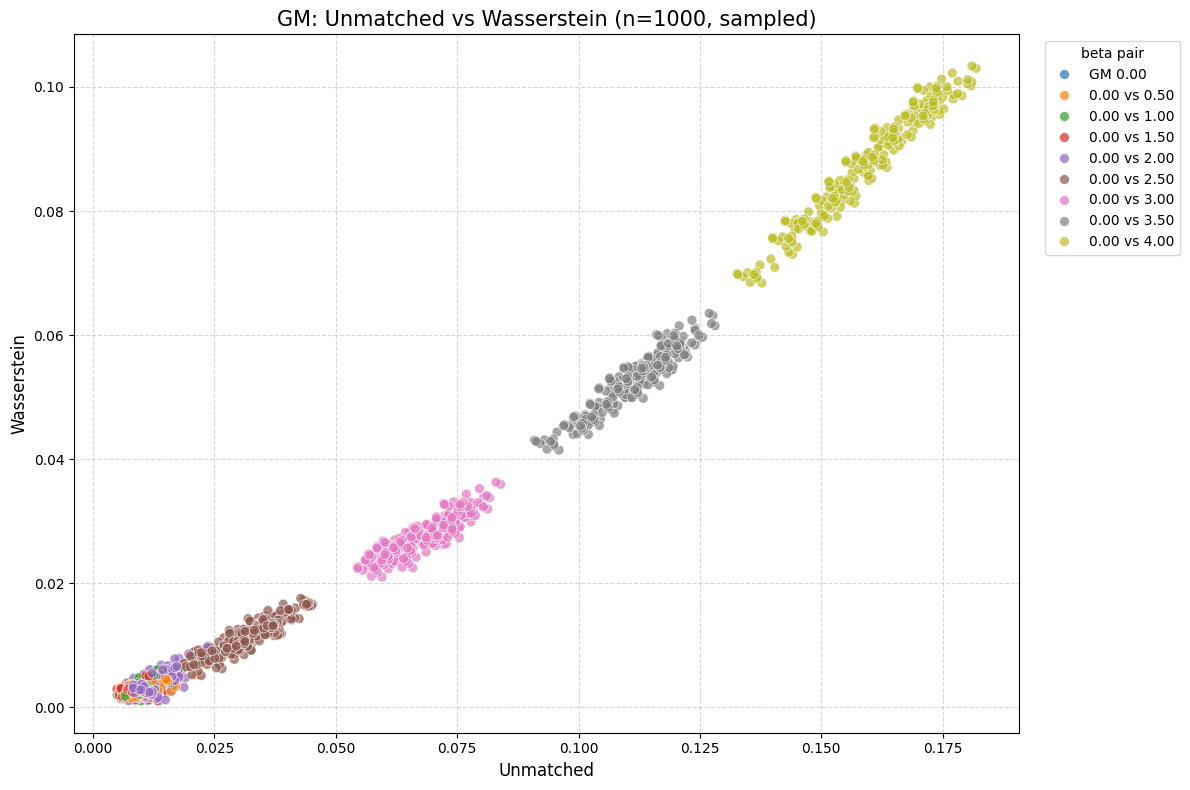

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


GM NMI globale - Unmatched:   0.6712
GM NMI globale - Wasserstein: 0.6603


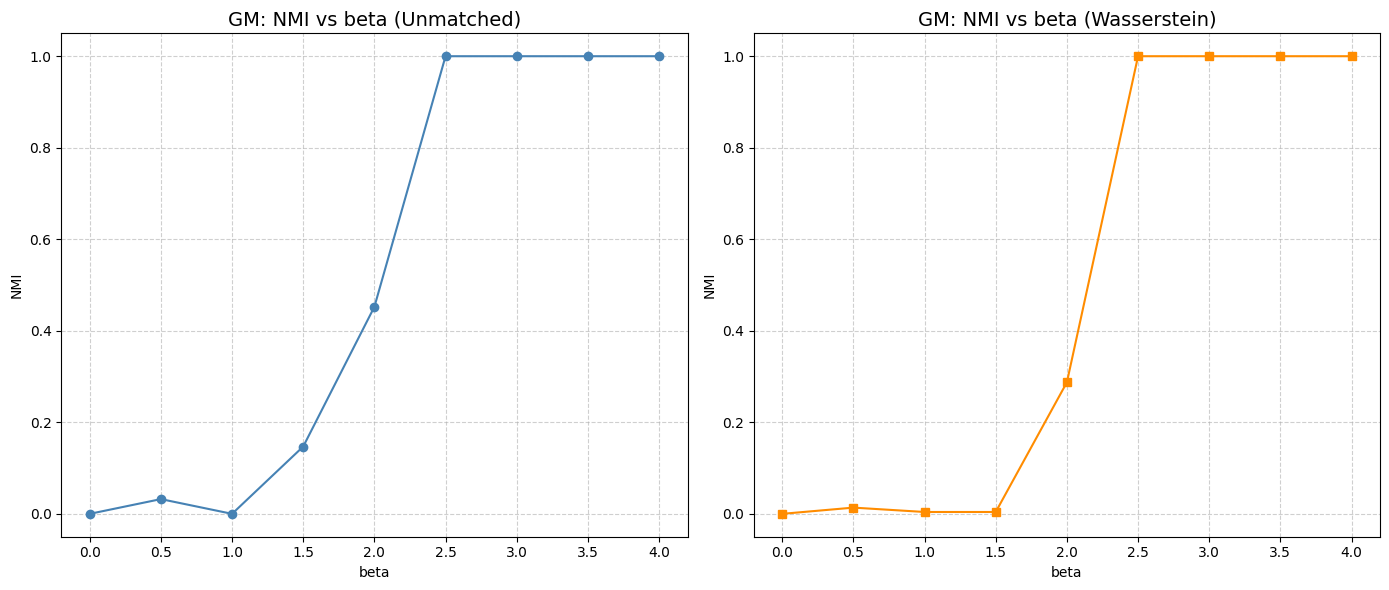

In [12]:
plot_scatter(df_gm, "GM", gm_betas, "beta pair")
nmi_global(D_unmatched_gm, D_wasserstein_gm, gm_betas, n_graphs, "GM")
nmi_u_gm_curve, nmi_w_gm_curve = nmi_curves(D_unmatched_gm, D_wasserstein_gm, gm_betas, n_graphs)
plot_nmi_curves(gm_betas, nmi_u_gm_curve, nmi_w_gm_curve, "GM", "beta")

## 4. Configuration Model via DCSBM (CM2)

Una sola comunità, `theta = Uniform(3,10)^alpha`. `alpha` crescente → hub più marcati.

In [13]:
df_cm2, D_unmatched_cm2, D_wasserstein_cm2, labels_cm2 = run_model_pipeline(
    "CM2", base_cm2, gen_cm_via_dcsbm,
    lambda a: (n_nodes, c, a, symmetric, make_connected),
    cm2_alphas, n_graphs, dim, m_samples, sample_seed)

Generazione CM2 param=0 -> data\synthetic_graphs\large\generated_cm2\param_0
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione CM2 param=0.5 -> data\synthetic_graphs\large\generated_cm2\param_0.5
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione CM2 param=1 -> data\synthetic_graphs\large\generated_cm2\param_1
[=======================> ] 100%


...

Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Generazione CM2 param=3 -> data\synthetic_graphs\large\generated_cm2\param_3
[=======================> ] 100%


Calcolando embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Pre-computing (sampled):   0%|          | 0/105 [00:00<?, ?it/s]

CM2 W2 (sampled):   0%|          | 0/5460 [00:00<?, ?it/s]

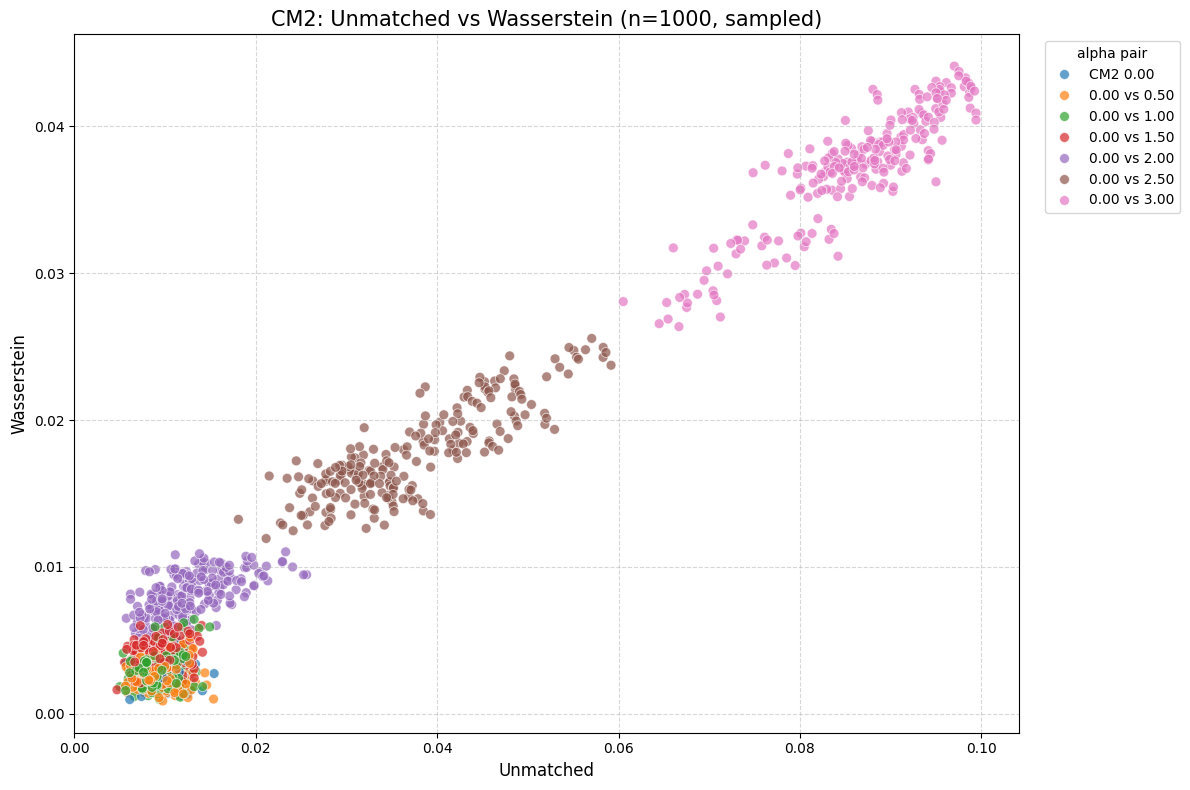

CM2 NMI globale - Unmatched:   0.5152
CM2 NMI globale - Wasserstein: 0.6655


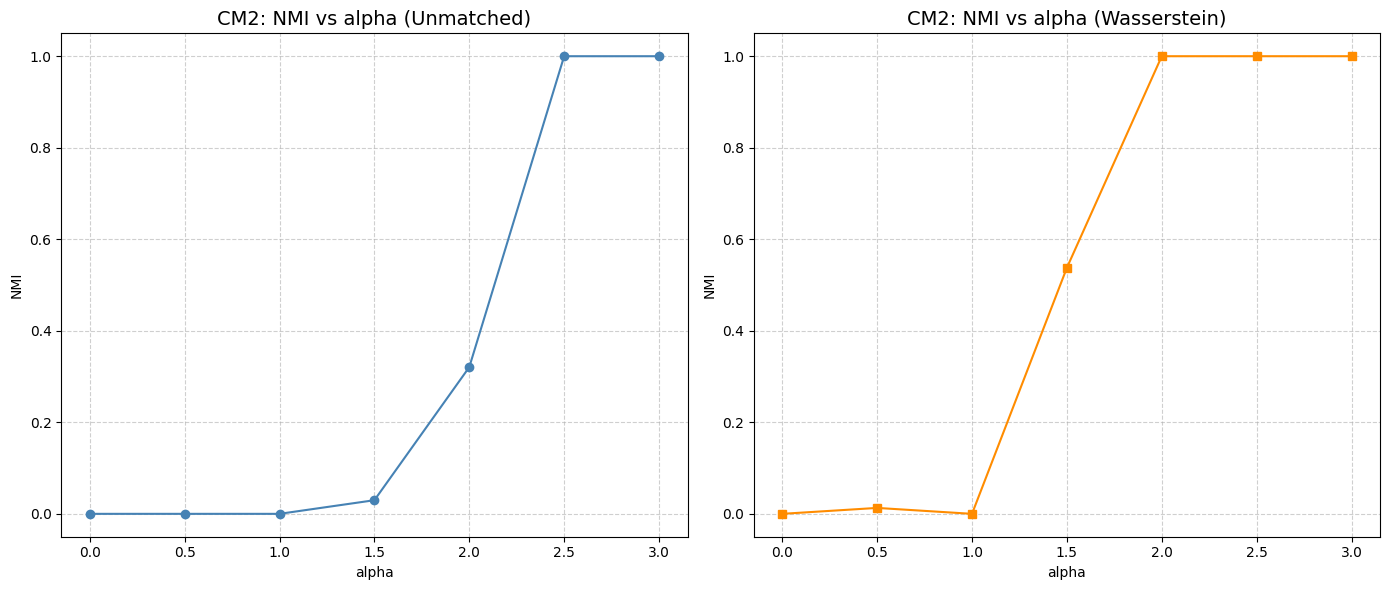

In [14]:
plot_scatter(df_cm2, "CM2", cm2_alphas, "alpha pair")
nmi_global(D_unmatched_cm2, D_wasserstein_cm2, cm2_alphas, n_graphs, "CM2")
nmi_u_cm2_curve, nmi_w_cm2_curve = nmi_curves(D_unmatched_cm2, D_wasserstein_cm2, cm2_alphas, n_graphs)
plot_nmi_curves(cm2_alphas, nmi_u_cm2_curve, nmi_w_cm2_curve, "CM2", "alpha")

## Confronto NMI tra tutti i modelli

Griglia 2x2 con le curve NMI vs parametro per SBM, CM, GM e CM2 (taglia grande, W2 campionata).

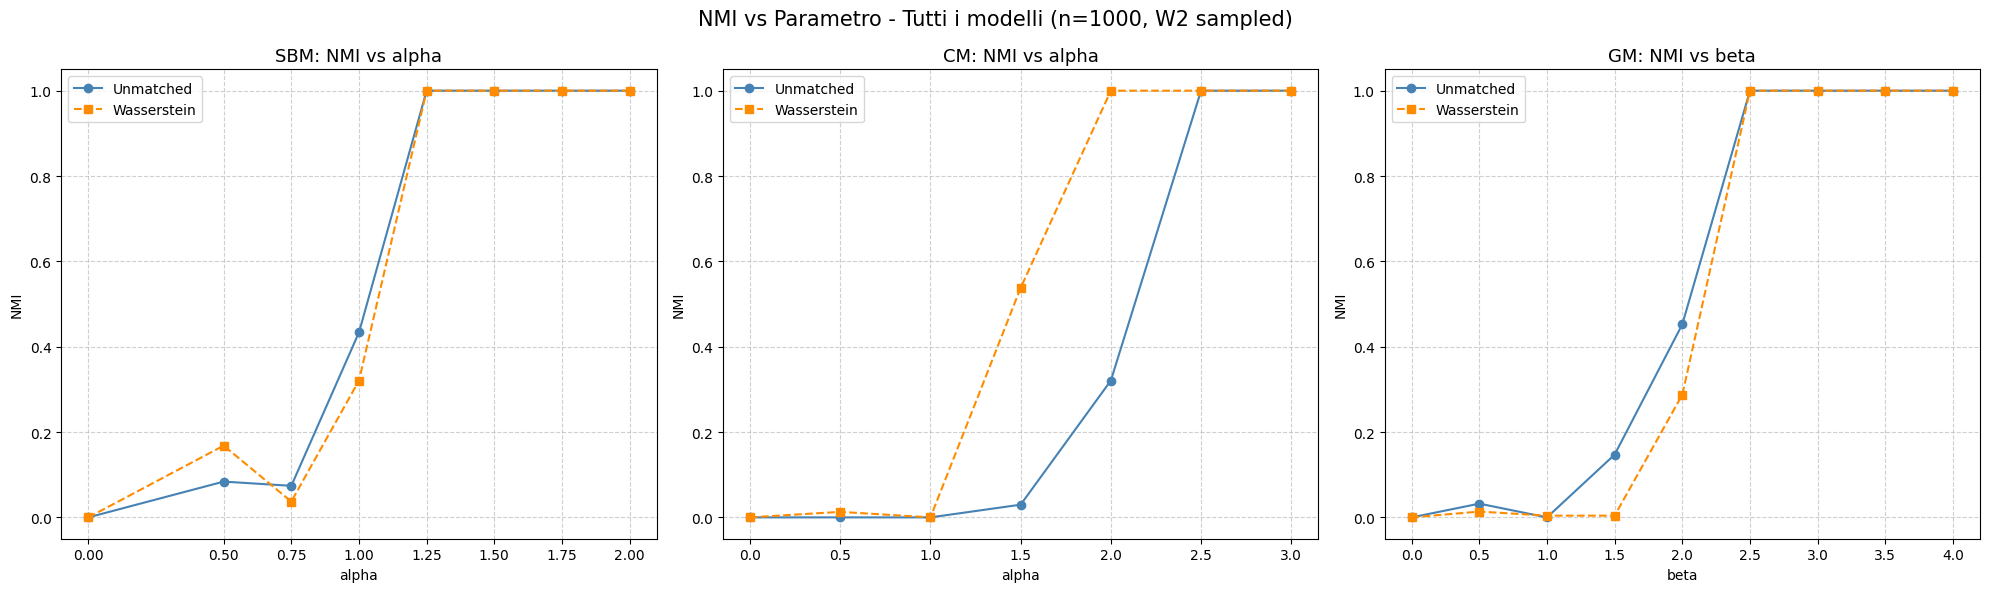

In [21]:
fig, axes = plt.subplots(1,3, figsize=(20, 6))
fig.suptitle(f"NMI vs Parametro - Tutti i modelli (n={n_nodes}, W2 sampled)", fontsize=15)

model_configs = [
    ("SBM",  sbm_alphas,  nmi_u_sbm_curve,  nmi_w_sbm_curve,  "alpha"),
    ("CM",  cm2_alphas,  nmi_u_cm2_curve,  nmi_w_cm2_curve,  "alpha"),
    ("GM",   gm_betas,    nmi_u_gm_curve,   nmi_w_gm_curve,   "beta")]
    

for ax, (name, params, nmi_u, nmi_w, xlabel) in zip(axes.ravel(), model_configs):
    ax.plot(params, nmi_u, marker="o", color="steelblue",  linestyle="-",  label="Unmatched")
    ax.plot(params, nmi_w, marker="s", color="darkorange", linestyle="--", label="Wasserstein")
    ax.set_title(f"{name}: NMI vs {xlabel}", fontsize=13)
    ax.set_xlabel(xlabel); ax.set_ylabel("NMI")
    ax.set_xticks(params); ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=10)

plt.tight_layout(); plt.show()